# Práctica de PySpark ML: predicción de costes médicos

**Dataset:** [Insurance](https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv)  
**Variable objetivo:** `charges` (costes médicos individuales facturados)  
**Semilla de reproducibilidad:** 42

La práctica mantiene claramente separadas las dos partes del enunciado:

1. **EDA con la API de pandas de PySpark** (`pyspark.pandas`).
2. **Preparación y regresión lineal con `pyspark.ml`** sobre un DataFrame normal de Spark.

> Las transformaciones que aprenden parámetros (`StringIndexer` y `StandardScaler`) se ajustan
> únicamente con el conjunto de entrenamiento al formar parte del `Pipeline`.

## Comprobación del entorno en Google Colab

Esta celda comprueba automáticamente si PySpark está disponible. Sólo en Google Colab y cuando
PySpark no esté instalado, instalará **Java 17 y PySpark 3.5.1 porque son las versiones propuestas
expresamente en el enunciado**, no por una decisión arbitraria.
En un entorno local no realiza instalaciones: muestra las instrucciones necesarias.

In [1]:
# Esta celda es segura tanto en Colab como en un ordenador local.
import importlib.util
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
PYSPARK_AVAILABLE = importlib.util.find_spec("pyspark") is not None

if IN_COLAB and not PYSPARK_AVAILABLE:
    print("PySpark no está instalado. Preparando Java 17 y PySpark 3.5.1...")
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(
        ["apt-get", "install", "-y", "openjdk-17-jdk-headless", "-qq"],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pyspark==3.5.1"],
        check=True,
    )
    os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
    os.environ["PATH"] += ":/usr/lib/jvm/java-17-openjdk-amd64/bin"
    print("Instalación terminada. Ya se puede continuar con la siguiente celda.")
elif PYSPARK_AVAILABLE:
    import pyspark
    print(f"PySpark ya está disponible (versión {pyspark.__version__}).")
else:
    print("PySpark no está instalado. En local, consulta requirements.txt y README.md.")

PySpark ya está disponible (versión 4.0.3).


# Parte 1 (6 puntos): EDA con la API de pandas de PySpark

## 1.1. Inicio de Spark y carga reproducible

Spark no interpreta una URL HTTPS como una ruta de fichero ordinaria. Por eso se usa la copia local
`insurance.csv` y, si no existe (por ejemplo, al subir sólo el notebook a Colab), se descarga primero.
El análisis posterior sí se realiza sobre un `pyspark.pandas.DataFrame`. También se desactiva el
modo ANSI: Spark 4.x lo activa por defecto, pero algunas operaciones de pandas API de PySpark lo
rechazan para evitar diferencias de comportamiento con pandas.

In [2]:
from pathlib import Path
from urllib.request import urlretrieve
import os
import sys

# Evita una advertencia frecuente al intercambiar timestamps mediante Arrow.
os.environ.setdefault("PYARROW_IGNORE_TIMEZONE", "1")

import matplotlib.pyplot as plt
import pandas as pd
import pyspark
import pyspark.pandas as ps
from IPython.display import display
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("Práctica PySpark ML - Insurance")
    # Compatible con PySpark 3.5.1 y con Spark 4.x de Colab.
    .config("spark.sql.ansi.enabled", "false")
    .getOrCreate()
)
# getOrCreate() puede reutilizar una sesión existente; por eso se fuerza también aquí.
spark.conf.set("spark.sql.ansi.enabled", "false")
spark.sparkContext.setLogLevel("WARN")
ps.set_option("compute.default_index_type", "distributed")

SEED = 42
DATASET_URL = (
    "https://raw.githubusercontent.com/stedy/"
    "Machine-Learning-with-R-datasets/master/insurance.csv"
)

local_candidates = [Path("insurance.csv"), Path("/content/insurance.csv")]
dataset_path = next((path for path in local_candidates if path.exists()), Path("insurance.csv"))
if not dataset_path.exists():
    print("No se encontró el CSV local; se descarga desde la fuente indicada.")
    urlretrieve(DATASET_URL, dataset_path)

# A partir de aquí trabajamos con pandas API de PySpark, no con pandas tradicional.
psdf = ps.read_csv(str(dataset_path.resolve()))
expected_columns = {"age", "sex", "bmi", "children", "smoker", "region", "charges"}
missing_columns = expected_columns - set(psdf.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas obligatorias: {sorted(missing_columns)}")
print(f"Dataset cargado desde: {dataset_path.resolve()}")
print(f"Python: {sys.version.split()[0]} | PySpark: {pyspark.__version__} | Spark: {spark.version}")
print(f"Java: {spark._jvm.java.lang.System.getProperty('java.version')} | Modo ANSI: {spark.conf.get('spark.sql.ansi.enabled')}")
display(psdf.head())

No se encontró el CSV local; se descarga desde la fuente indicada.


/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `read_csv`, the default index is attached which can cause additional overhead.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


Dataset cargado desde: /content/insurance.csv
Python: 3.12.13 | PySpark: 4.0.3 | Spark: 4.0.3
Java: 17.0.19 | Modo ANSI: false


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1.2. Estructura, tipos y calidad inicial

Se comprueban dimensiones, esquema lógico, nulos y duplicados. Un duplicado exacto puede sesgar
ligeramente el ajuste al otorgar más peso a una observación; se documenta aquí y se eliminará antes
del modelado, sin alterar el objeto usado para el EDA.

In [3]:
# shape provoca un recuento distribuido de las filas.
print(f"Dimensiones: {psdf.shape[0]} filas y {psdf.shape[1]} columnas")
print("\nTipos de datos:")
display(psdf.dtypes.rename("tipo"))

print("\nValores nulos por columna:")
display(psdf.isnull().sum().rename("nulos"))

# Un duplicado exacto repite los valores de las siete columnas.
duplicate_count = int(psdf.duplicated().sum())
print(f"\nFilas completamente duplicadas: {duplicate_count}")
if duplicate_count:
    display(psdf[psdf.duplicated(keep=False)].sort_values(list(psdf.columns)))

Dimensiones: 1338 filas y 7 columnas

Tipos de datos:


,tipo
age,int32
sex,object
bmi,float64
children,int32
smoker,object
region,object
charges,float64



Valores nulos por columna:


/usr/local/lib/python3.12/dist-packages/pyspark/pandas/generic.py:1373: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  warnings.warn(


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
Name: nulos, dtype: int64


Filas completamente duplicadas: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


## 1.3. Estadísticos de las variables numéricas

Además del resumen clásico, se calcula la asimetría de `charges` y se aplica la regla del rango
intercuartílico (IQR) como diagnóstico descriptivo. Las observaciones extremas no se eliminan de
forma automática: en costes sanitarios pueden ser casos reales y relevantes.

In [4]:
numeric_columns = ["age", "bmi", "children", "charges"]
display(psdf[numeric_columns].describe())

# Regla IQR: ayuda a describir valores extremos, pero no implica que sean errores.
q1 = float(psdf["charges"].quantile(0.25))
q3 = float(psdf["charges"].quantile(0.75))
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
high_charge_count = int((psdf["charges"] > upper_limit).sum())

print(f"Asimetría de charges: {float(psdf['charges'].skew()):.3f}")
print(f"Límite superior IQR: {upper_limit:,.2f}")
print(f"Casos por encima del límite: {high_charge_count}")

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4738.268200
50%,39.000000,30.400000,1.000000,9377.904700
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


Asimetría de charges: 1.516
Límite superior IQR: 34,536.89
Casos por encima del límite: 139


## 1.4. Distribución de las variables categóricas

Se muestran frecuencias absolutas y porcentajes para detectar categorías imprevistas y posibles
desequilibrios. Esta comprobación también justifica la codificación posterior.

In [5]:
categorical_columns = ["sex", "smoker", "region"]
categorical_tables = {}

# Se reutiliza el mismo cálculo para las tres variables categóricas.
for column in categorical_columns:
    frequencies = psdf[column].value_counts().sort_index()
    table = frequencies.rename("frecuencia").to_frame()
    table["porcentaje"] = (table["frecuencia"] / len(psdf) * 100).round(2)
    categorical_tables[column] = table
    print(f"Distribución de '{column}':")
    display(table)

Distribución de 'sex':


,frecuencia,porcentaje
sex,,
female,662,49.48
male,676,50.52


Distribución de 'smoker':


,frecuencia,porcentaje
smoker,,
no,1064,79.52
yes,274,20.48


Distribución de 'region':


,frecuencia,porcentaje
region,,
northeast,324,24.22
northwest,325,24.29
southeast,364,27.20
southwest,325,24.29


## 1.5. Relación de las variables con `charges`

Las frecuencias del apartado anterior informan del tamaño de cada grupo; ahora se comparan sus medias.
La comparación conjunta de tabaquismo y sexo ayuda a comprobar si la diferencia por sexo persiste
dentro de cada condición de fumador.

In [6]:
# Se usa GroupBy.mean() en vez de agg([...]) porque esta última operación
# no está implementada en todas las versiones de pandas API de PySpark.
for column in categorical_columns:
    mean_charges = (
        psdf.groupby(column)["charges"]
        .mean()
        .sort_values(ascending=False)
        .rename("coste_medio")
    )
    print(f"Coste medio según '{column}':")
    display(mean_charges.round(2))

print("Charges por condición de fumador y sexo:")
display(
    psdf.groupby(["smoker", "sex"])["charges"]
    .mean()
    .rename("coste_medio")
    .round(2)
)

Coste medio según 'sex':


sex
male      13956.75
female    12569.58
Name: coste_medio, dtype: float64

Coste medio según 'smoker':


smoker
yes    32050.23
no      8434.27
Name: coste_medio, dtype: float64

Coste medio según 'region':


region
southeast    14735.41
northeast    13406.38
northwest    12417.58
southwest    12346.94
Name: coste_medio, dtype: float64

Charges por condición de fumador y sexo:


smoker  sex   
no      female     8762.30
yes     female    30679.00
        male      33042.01
no      male       8087.20
Name: coste_medio, dtype: float64

## 1.6. Correlaciones y visualizaciones

La correlación de Pearson mide asociación lineal, no causalidad. Para dibujar se materializan sólo
las cuatro columnas necesarias con `.to_pandas()`. Esta conversión es segura aquí porque el dataset
tiene 1.338 filas; el EDA y los cálculos anteriores siguen realizándose con pandas API de PySpark.

,age,bmi,children,charges
age,1.000,0.109,0.042,0.299
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.068
charges,0.299,0.198,0.068,1.000


/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas DataFrame is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/tmp/ipykernel_708/4102559592.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(groups, labels=["No", "Sí"], showfliers=True)


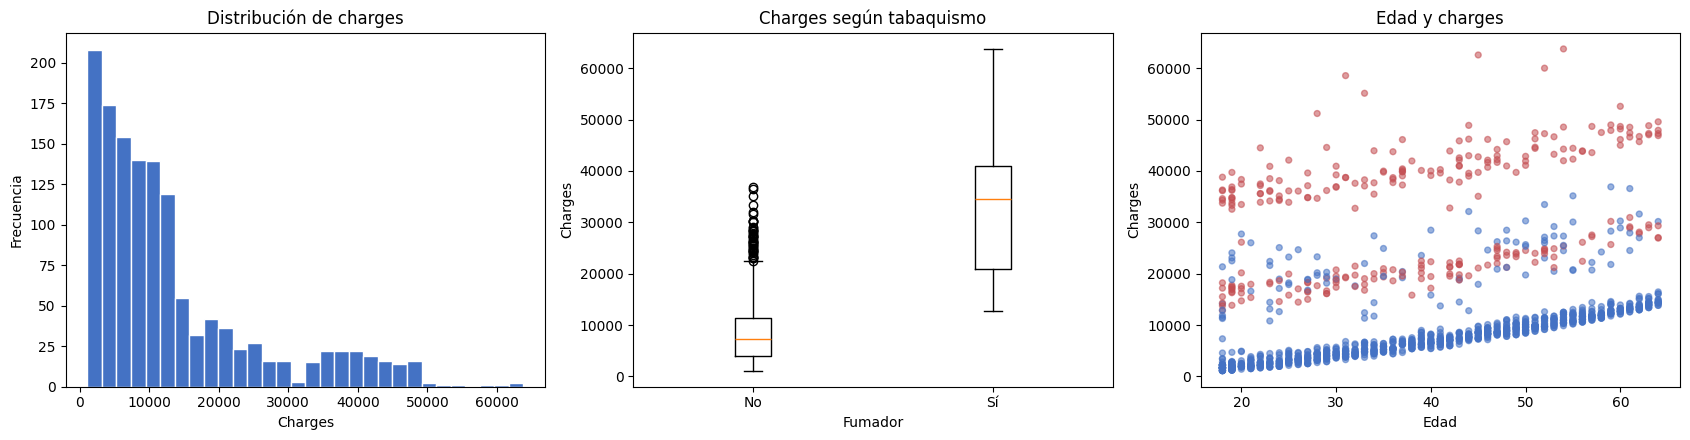

In [7]:
# Pearson resume relaciones lineales entre pares de variables numéricas.
correlations = psdf[numeric_columns].corr()
display(correlations.round(3))

plot_data = psdf[["age", "bmi", "smoker", "charges"]].to_pandas()
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].hist(plot_data["charges"], bins=30, color="#4472C4", edgecolor="white")
axes[0].set(title="Distribución de charges", xlabel="Charges", ylabel="Frecuencia")

groups = [
    plot_data.loc[plot_data["smoker"] == value, "charges"]
    for value in ["no", "yes"]
]
axes[1].boxplot(groups, labels=["No", "Sí"], showfliers=True)
axes[1].set(title="Charges según tabaquismo", xlabel="Fumador", ylabel="Charges")

colors = plot_data["smoker"].map({"no": "#4472C4", "yes": "#C44E52"})
axes[2].scatter(plot_data["age"], plot_data["charges"], c=colors, alpha=0.55, s=18)
axes[2].set(title="Edad y charges", xlabel="Edad", ylabel="Charges")

fig.tight_layout()
plt.show()

## 1.7. Conclusiones del EDA

- El dataset contiene **1.338 registros y 7 variables**, sin valores nulos en su versión original.
- Existe **un duplicado exacto**, que se eliminará antes de dividir los datos.
- `charges` presenta una distribución claramente asimétrica a la derecha y casos de coste elevado;
  se conservan porque no hay evidencia de que sean errores.
- La condición de **fumador** es la separación descriptiva más marcada: el gasto medio de fumadores
  es varias veces superior al de no fumadores.
- La edad y, en menor medida, el IMC muestran asociación positiva con el coste. La correlación no
  permite afirmar causalidad ni recoge relaciones no lineales o interacciones.
- `sex`, `smoker` y `region` deben codificarse; `age`, `bmi` y `children` son predictores numéricos.
- El modelo lineal será una base interpretable. Su rendimiento puede estar limitado por la asimetría,
  los costes extremos y posibles interacciones como `smoker × bmi`.

# Parte 2 (4 puntos): regresión lineal con `pyspark.ml`

## 2.1. Conversión a DataFrame de Spark y limpieza

Se convierte el mismo objeto de pandas API de PySpark con `to_spark()`. Después se fuerzan los tipos,
se normaliza el texto, se comprueban `null`/`NaN` y se elimina el duplicado exacto. `charges` no se
incluye entre las características, pues es la etiqueta que se desea predecir.

In [8]:
from pyspark.sql.functions import avg, col, count, isnan, lit, lower, trim, when

# Desde este punto se abandona pandas API y se usa un DataFrame de Spark.
df = psdf.to_spark()

for column in numeric_columns:
    df = df.withColumn(column, col(column).cast("double"))
for column in categorical_columns:
    df = df.withColumn(column, lower(trim(col(column))))

print("Esquema tras la conversión:")
df.printSchema()

null_checks = []
for column in df.columns:
    invalid = col(column).isNull()
    if column in numeric_columns:
        invalid = invalid | isnan(column)
    null_checks.append(count(when(invalid, column)).alias(column))

print("Nulos o NaN por columna:")
df.select(null_checks).show()

rows_before = df.count()
df_clean = df.dropna(subset=numeric_columns + categorical_columns).dropDuplicates()
rows_after = df_clean.count()
print(f"Filas antes de limpiar: {rows_before}; filas después: {rows_after}")

# Validación reproducible: la limpieza debe retirar exactamente los duplicados detectados.
assert rows_after == rows_before - duplicate_count, (
    "La diferencia de filas no coincide con los duplicados detectados."
)

# Los valores numéricos imposibles se detectan antes de entrenar el modelo.
invalid_numeric_rows = df_clean.filter(
    (col("age") <= 0)
    | (col("bmi") <= 0)
    | (col("children") < 0)
    | (col("charges") < 0)
).count()
assert invalid_numeric_rows == 0, f"Hay {invalid_numeric_rows} filas con valores imposibles."
print("Validación numérica: no se han encontrado edades, IMC, hijos o costes imposibles.")

for column in categorical_columns:
    print(f"Categorías de {column}:")
    df_clean.groupBy(column).count().orderBy(column).show()

# También se verifica que no hayan aparecido etiquetas desconocidas.
expected_categories = {
    "sex": {"female", "male"},
    "smoker": {"no", "yes"},
    "region": {"northeast", "northwest", "southeast", "southwest"},
}
for column, expected in expected_categories.items():
    observed = {row[column] for row in df_clean.select(column).distinct().collect()}
    assert observed <= expected, f"Categorías inesperadas en {column}: {sorted(observed - expected)}"
print("Validación categórica: todas las etiquetas pertenecen al dominio esperado.")

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `to_spark`, the existing index is lost when converting to Spark DataFrame.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


Esquema tras la conversión:
root
 |-- age: double (nullable = true)
 |-- sex: string (nullable = true)
 |-- bmi: double (nullable = true)
 |-- children: double (nullable = true)
 |-- smoker: string (nullable = true)
 |-- region: string (nullable = true)
 |-- charges: double (nullable = true)

Nulos o NaN por columna:
+---+---+---+--------+------+------+-------+
|age|sex|bmi|children|smoker|region|charges|
+---+---+---+--------+------+------+-------+
|  0|  0|  0|       0|     0|     0|      0|
+---+---+---+--------+------+------+-------+

Filas antes de limpiar: 1338; filas después: 1337
Validación numérica: no se han encontrado edades, IMC, hijos o costes imposibles.
Categorías de sex:
+------+-----+
|   sex|count|
+------+-----+
|female|  662|
|  male|  675|
+------+-----+

Categorías de smoker:
+------+-----+
|smoker|count|
+------+-----+
|    no| 1063|
|   yes|  274|
+------+-----+

Categorías de region:
+---------+-----+
|   region|count|
+---------+-----+
|northeast|  324|
|north

## 2.2. División entrenamiento/prueba

Se reserva aproximadamente un 20 % para evaluar datos no usados en el ajuste. La semilla fija hace
reproducible la división. Se cachean ambos subconjuntos porque se reutilizarán varias veces.

In [9]:
# La semilla hace repetible la asignación de filas a train y test.
train_df, test_df = df_clean.randomSplit([0.8, 0.2], seed=SEED)
train_df = train_df.cache()
test_df = test_df.cache()

train_count = train_df.count()
test_count = test_df.count()
assert train_count > 0 and test_count > 0, "La división ha generado un subconjunto vacío."
assert train_count + test_count == rows_after, "Se han perdido filas durante la división."
print(f"Entrenamiento: {train_count} filas ({train_count / rows_after:.1%})")
print(f"Prueba:        {test_count} filas ({test_count / rows_after:.1%})")

Entrenamiento: 1070 filas (80.0%)
Prueba:        267 filas (20.0%)


## 2.3. Pipeline de transformación y regresión

Flujo de cada observación:

1. `StringIndexer` convierte las categorías en índices.
2. `OneHotEncoder` evita imponer un orden artificial entre categorías.
3. `VectorAssembler` reúne las variables numéricas.
4. `StandardScaler` centra y escala sólo los predictores numéricos.
5. Un segundo `VectorAssembler` crea la columna `features`.
6. `LinearRegression` aprende a predecir `charges`.

`handleInvalid="keep"` permite transformar categorías nuevas en datos futuros. Como todo está dentro
del `Pipeline`, índices y escala se aprenden únicamente de `train_df`, evitando fuga de información.

In [10]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import OneHotEncoder, StandardScaler, StringIndexer, VectorAssembler
from pyspark.ml.regression import LinearRegression

numeric_features = ["age", "bmi", "children"]

# Los indexadores aprenden las categorías únicamente al ajustar el Pipeline con train.
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep")
    for c in categorical_columns
]

encoder = OneHotEncoder(
    inputCols=[f"{c}_index" for c in categorical_columns],
    outputCols=[f"{c}_ohe" for c in categorical_columns],
    handleInvalid="keep",
    dropLast=True,
)

numeric_assembler = VectorAssembler(
    inputCols=numeric_features,
    outputCol="numeric_features",
    handleInvalid="error",
)

scaler = StandardScaler(
    inputCol="numeric_features",
    outputCol="scaled_numeric_features",
    withMean=True,
    withStd=True,
)

final_assembler = VectorAssembler(
    inputCols=["scaled_numeric_features"] + [f"{c}_ohe" for c in categorical_columns],
    outputCol="features",
    handleInvalid="error",
)

linear_regression = LinearRegression(
    featuresCol="features",
    labelCol="charges",
    predictionCol="prediction",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0,
)

pipeline = Pipeline(
    stages=indexers
    + [encoder, numeric_assembler, scaler, final_assembler, linear_regression]
)

pipeline_model = pipeline.fit(train_df)
predictions = pipeline_model.transform(test_df).cache()
print("Pipeline ajustado correctamente.")

Pipeline ajustado correctamente.


## 2.4. Predicciones y métricas

- **RMSE:** penaliza especialmente los errores grandes y conserva las unidades monetarias.
- **MAE:** error absoluto medio, también en unidades monetarias y más resistente a casos extremos.
- **R²:** proporción de variabilidad explicada respecto a predecir una constante.

Además se compara el modelo con una referencia ingenua que siempre predice la media de `charges`
del conjunto de entrenamiento. Una regresión útil debería reducir claramente RMSE y MAE frente a ella.

In [11]:
from pyspark.ml.evaluation import RegressionEvaluator

# Prueba de humo: debe existir exactamente una predicción válida por fila de test.
prediction_count = predictions.count()
invalid_predictions = predictions.filter(
    col("prediction").isNull() | isnan("prediction")
).count()
assert prediction_count == test_count, "El número de predicciones no coincide con test."
assert invalid_predictions == 0, "El modelo ha producido predicciones nulas o NaN."
print(f"Prueba de humo superada: {prediction_count} predicciones válidas.")

predictions.select(
    "age", "sex", "bmi", "children", "smoker", "region", "charges", "prediction"
).show(10, truncate=False)

# Todas las métricas se calculan exclusivamente con el conjunto de prueba.
metrics = {}
for metric_name in ["rmse", "mae", "r2"]:
    evaluator = RegressionEvaluator(
        labelCol="charges",
        predictionCol="prediction",
        metricName=metric_name,
    )
    metrics[metric_name] = evaluator.evaluate(predictions)

print(f"RMSE: {metrics['rmse']:,.2f}")
print(f"MAE:  {metrics['mae']:,.2f}")
print(f"R²:   {metrics['r2']:.4f}")

train_mean = train_df.select(avg("charges").alias("mean_charge")).first()["mean_charge"]
baseline_predictions = predictions.withColumn("baseline_prediction", lit(train_mean))
baseline_metrics = {}
for metric_name in ["rmse", "mae"]:
    evaluator = RegressionEvaluator(
        labelCol="charges",
        predictionCol="baseline_prediction",
        metricName=metric_name,
    )
    baseline_metrics[metric_name] = evaluator.evaluate(baseline_predictions)

print("\nModelo base (media de train):")
print(f"RMSE base: {baseline_metrics['rmse']:,.2f}")
print(f"MAE base:  {baseline_metrics['mae']:,.2f}")
rmse_reduction = 1 - metrics["rmse"] / baseline_metrics["rmse"]
print(f"Reducción de RMSE: {rmse_reduction:.1%}")

# Interpretación ligada a los valores realmente calculados, no a cifras escritas a mano.
print("\nInterpretación:")
print(f"- La regresión reduce el RMSE un {rmse_reduction:.1%} frente a predecir siempre la media.")
if metrics["r2"] >= 0.75:
    print("- El modelo explica una proporción alta de la variabilidad de charges en test.")
elif metrics["r2"] >= 0.50:
    print("- El modelo explica una proporción moderada de la variabilidad de charges en test.")
else:
    print("- La capacidad explicativa es limitada; convendría revisar supuestos y alternativas.")

Prueba de humo superada: 267 predicciones válidas.
+----+------+------+--------+------+---------+----------+------------------+
|age |sex   |bmi   |children|smoker|region   |charges   |prediction        |
+----+------+------+--------+------+---------+----------+------------------+
|19.0|male  |29.07 |0.0     |yes   |northwest|17352.6803|26169.25185957177 |
|29.0|male  |22.515|3.0     |no    |northeast|5209.57885|4481.073083537927 |
|32.0|female|41.1  |0.0     |no    |southwest|3989.841  |9489.70809978335  |
|18.0|female|31.35 |0.0     |no    |southeast|1622.1885 |2569.844824194144 |
|39.0|male  |32.34 |2.0     |no    |southeast|6338.0756 |9085.194459287992 |
|43.0|male  |20.13 |2.0     |yes   |southeast|18767.7377|29683.159687715146|
|34.0|female|37.335|2.0     |no    |northwest|5989.52365|9992.604428785235 |
|27.0|male  |28.5  |0.0     |yes   |northwest|18310.742 |27993.996722893942|
|39.0|male  |28.3  |1.0     |yes   |southwest|21082.16  |31017.519355365555|
|47.0|female|45.32 |1.0  

## 2.5. Coeficientes y análisis de residuos

Los coeficientes numéricos corresponden a variables estandarizadas: expresan el cambio esperado en
`charges` al aumentar una desviación típica, manteniendo el resto constante. Las variables one-hot
se interpretan respecto a la categoría omitida. Son asociaciones del modelo, no efectos causales.

In [12]:
# La regresión es la última etapa del Pipeline ya ajustado.
lr_model = pipeline_model.stages[-1]
print(f"Intercepto: {lr_model.intercept:,.2f}")

# Spark conserva en 'features' metadatos con los nombres tras el ensamblado.
feature_metadata = predictions.schema["features"].metadata.get("ml_attr", {}).get("attrs", {})
attributes = [item for group in feature_metadata.values() for item in group]
attributes = sorted(attributes, key=lambda item: item["idx"])
feature_names = [item.get("name", f"feature_{item['idx']}") for item in attributes]
if len(feature_names) != len(lr_model.coefficients):
    feature_names = [f"feature_{i}" for i in range(len(lr_model.coefficients))]

coefficient_table = pd.DataFrame(
    {"variable_transformada": feature_names, "coeficiente": list(lr_model.coefficients)}
)
coefficient_table["valor_absoluto"] = coefficient_table["coeficiente"].abs()
display(coefficient_table.sort_values("valor_absoluto", ascending=False).drop(columns="valor_absoluto"))

Intercepto: 20,451.21


,variable_transformada,coeficiente
7,smoker_ohe_yes,11961.724697
6,smoker_ohe_no,-11961.724697
0,scaled_numeric_features_0,3553.852722
1,scaled_numeric_features_1,2175.355747
11,region_ohe_northeast,670.791562
2,scaled_numeric_features_2,545.083700
10,region_ohe_southwest,-381.068211
9,region_ohe_southeast,-288.226401
3,sex_ohe_female,41.643770
4,sex_ohe_male,-41.643770


Resumen de residuos en test:
+------------------+------------------+
|     media_residuo|desviacion_residuo|
+------------------+------------------+
|-394.2866675456438| 5589.731398451158|
+------------------+------------------+



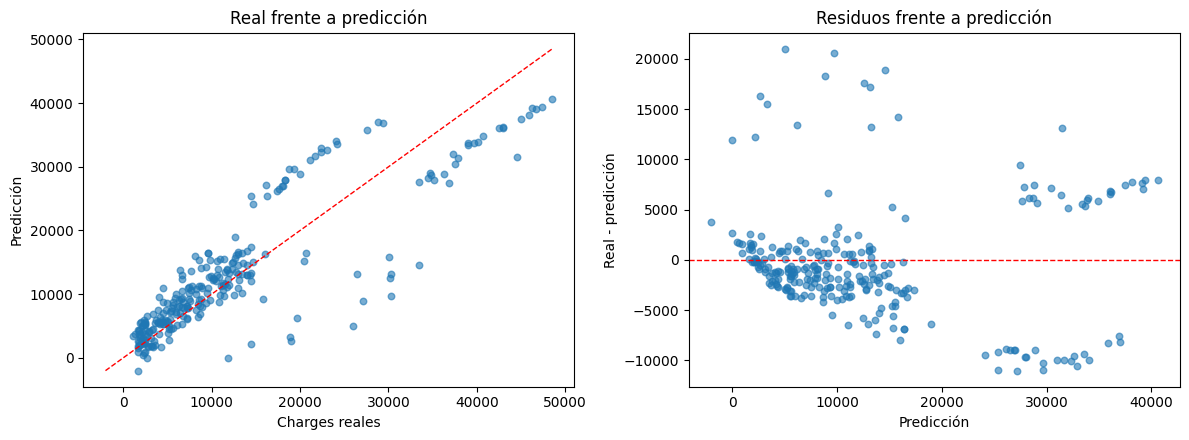

In [13]:
from pyspark.sql.functions import mean, stddev

# Residuo positivo: el coste real fue superior al estimado por el modelo.
residual_predictions = predictions.withColumn("residual", col("charges") - col("prediction"))
print("Resumen de residuos en test:")
residual_predictions.select(
    mean("residual").alias("media_residuo"),
    stddev("residual").alias("desviacion_residuo"),
).show()

test_plot = residual_predictions.select("charges", "prediction", "residual").toPandas()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(test_plot["charges"], test_plot["prediction"], alpha=0.6, s=22)
line_min = min(test_plot["charges"].min(), test_plot["prediction"].min())
line_max = max(test_plot["charges"].max(), test_plot["prediction"].max())
axes[0].plot([line_min, line_max], [line_min, line_max], "r--", linewidth=1)
axes[0].set(title="Real frente a predicción", xlabel="Charges reales", ylabel="Predicción")

axes[1].scatter(test_plot["prediction"], test_plot["residual"], alpha=0.6, s=22)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set(title="Residuos frente a predicción", xlabel="Predicción", ylabel="Real - predicción")

fig.tight_layout()
plt.show()

## Conclusión final y comprobación del enunciado

Se ha completado el flujo solicitado con separación estricta entre APIs:

- El EDA se ha realizado sobre un `pyspark.pandas.DataFrame`.
- Los datos se han convertido después a un DataFrame normal de Spark.
- La preparación y la regresión se han implementado con `pyspark.ml` dentro de un `Pipeline`.
- La evaluación se hace sobre un conjunto de prueba independiente y se compara con una referencia base.

### Lista de comprobación para la corrección

- ✅ EDA realizado con `pyspark.pandas`.
- ✅ Conversión posterior a un DataFrame normal de Spark.
- ✅ Variables categóricas transformadas con `StringIndexer` y `OneHotEncoder`.
- ✅ Variables numéricas reunidas con `VectorAssembler` y escaladas con `StandardScaler`.
- ✅ Regresión lineal entrenada exclusivamente con el conjunto de entrenamiento.
- ✅ Evaluación independiente mediante RMSE, MAE y R², con comparación frente a un modelo base.
- ✅ Validaciones de datos, división y predicciones ejecutadas como pruebas de humo.

En este problema, la regresión lineal suele mejorar claramente la predicción constante gracias sobre
todo a la información de tabaquismo, edad e IMC. Sin embargo, los residuos y los costes extremos
muestran que una relación puramente aditiva y lineal no captura toda la complejidad. Como extensión
futura sería razonable comparar una transformación `log1p(charges)`, añadir interacciones justificadas
o evaluar modelos no lineales, siempre manteniendo el conjunto de prueba aislado.

In [14]:
# Liberación opcional de recursos al terminar la práctica.
predictions.unpersist()
train_df.unpersist()
test_df.unpersist()
spark.stop()
print("Sesión de Spark detenida.")

Sesión de Spark detenida.
